In [1]:
!pip install PyMuPDF
!pip install pythainlp
!pip install evaluate
!apt-get update
!apt-get install -y poppler-utils tesseract-ocr tesseract-ocr-tha


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 79.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 63.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 10.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.5.1
    Uninstalling fsspec-2025.5.1:
      Successfully uninstalled fsspec-2025.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cub

In [2]:
import os
import pandas as pd
import re
from pythainlp.tokenize import word_tokenize
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from pdf2image import convert_from_path
import pytesseract
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
import evaluate



2025-08-11 11:54:40.497006: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754913280.728086      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754913280.792103      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:

def pdf_to_text_ocr(pdf_path):
    pages = convert_from_path(pdf_path, dpi=300)
    full_text = ""
    for page in pages:
        text = pytesseract.image_to_string(page, lang='tha')
        full_text += text + "\n"
    return full_text.strip()  # คืนข้อความที่ดึงได้


def add_text_column(df, pdf_folder):
    texts = []
    total_files = len(df)
    for idx, row in df.iterrows():
        pdf_name = row['pdf_name']
        pdf_path = os.path.join(pdf_folder, pdf_name)
        if os.path.exists(pdf_path):
            text = pdf_to_text_ocr(pdf_path)
        else:
            print(f"File not found: {pdf_path}")
            text = ""
        texts.append(text)

        # log progress ทุก ๆ 10 ไฟล์ หรือไฟล์สุดท้าย
        if (idx + 1) % 10 == 0 or (idx + 1) == total_files:
            print(f"Processed {idx + 1} / {total_files} files")

    df['text'] = texts
    return df


def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^ก-๙a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def thai_tokenize(text):
    tokens = word_tokenize(text, engine="newmm")
    return " ".join(tokens)

def preprocess_text_column(df, text_col='text', new_col='text_proc'):
    # ทำ clean และ tokenize แล้วรวมเป็นข้อความใหม่ในคอลัมน์ใหม่
    cleaned = df[text_col].apply(clean_text)
    tokenized = cleaned.apply(thai_tokenize)
    df[new_col] = tokenized
    return df 

In [ ]:

# เริ่มทำงาน
train_df = pd.read_csv('/kaggle/input/mitr-phol-gen-ai-hackathon/train.csv')
train_df = add_text_column(train_df, '/kaggle/input/mitr-phol-gen-ai-hackathon/train_docs')

train_df = preprocess_text_column(train_df, text_col='text', new_col='text_proc')

print(train_df[['pdf_name', 'bu_categories', 'action_non', 'text_proc']].head())
train_df.to_csv('train_processed1.csv', index=False)

In [3]:
train_df = pd.read_csv('/kaggle/input/pdf-to-text/train_processed.csv')

texts = train_df['text_proc'].tolist()
labels = train_df['result'].tolist()

# แปลง label เป็นตัวเลข
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
num_labels = len(label_encoder.classes_)

print(f"จำนวนคลาส: {num_labels}")
print(f"คลาส: {label_encoder.classes_}")

# สร้าง Dataset
dataset = Dataset.from_dict({
    "text": texts,
    "labels": labels_encoded
})


จำนวนคลาส: 32
คลาส: ['0_ACTION' 'AAW_NON' 'BIOCHEM_ACTION' 'BIOCHEM_NON' 'CONSUMER_ACTION'
 'CONSUMER_NON' 'ETHANOL_ACTION' 'ETHANOL_NON' 'FINANCE_ACTION'
 'FINANCE_NON' 'GENERAL_ACTION' 'GENERAL_NON' 'HR_ACTION' 'HR_NON'
 'IT_ACTION' 'MKT_ACTION' 'PNP_ACTION' 'PNP_NON' 'POWER_ACTION'
 'POWER_NON' 'QM_ACTION' 'QM_NON' 'RGS_ACTION' 'RGS_NON' 'SSHE_ACTION'
 'SSHE_NON' 'SUGAR_ACTION' 'SUGAR_NON' 'TIS_ACTION' 'TIS_NON' 'UST_ACTION'
 'UST_NON']


In [8]:
from transformers import TrainerCallback

# โหลด tokenizer และ model
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

history = {
    "epoch": [],
    "Validation Loss" : [],
    "accuracy": [],
    "f1": []
}

metric_acc = evaluate.load("accuracy") 
metric_f1 = evaluate.load("f1")

# ฟังก์ชันคำนวณ metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="weighted")
    

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"]
    }


# กำหนด preprocessing function
def preprocess_function(examples):
    tokenized = tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)
    tokenized["labels"] = examples["labels"]
    return tokenized

tokenized_dataset = dataset.map(preprocess_function, batched=True)

# กำหนด training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",  # บันทึกเมื่อจบ epoch
    save_total_limit=1,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=25,
    weight_decay=0.01,
    report_to=[],
)


class MetricsLoggerCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, *, metrics=None, **kwargs):
        if metrics is not None:
            history["epoch"].append(state.epoch)
            history["Validation Loss"].append(metrics.get("eval_loss"))
            history["accuracy"].append(metrics.get("eval_accuracy"))
            history["f1"].append(metrics.get("eval_f1"))
        return super().on_evaluate(args, state, control, metrics=metrics, **kwargs)

# สร้าง Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    eval_dataset=tokenized_dataset,
    compute_metrics=compute_metrics,
    callbacks=[MetricsLoggerCallback],
)

trainer.train()


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/1509 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,2.336133,0.398277,0.292467
2,No log,1.718643,0.526839,0.412902
3,No log,1.340625,0.655401,0.579056
4,No log,1.106379,0.687210,0.621190
5,No log,0.986865,0.722995,0.664726
6,1.706000,0.902325,0.746852,0.697469
7,1.706000,0.794521,0.776673,0.727529
8,1.706000,0.708960,0.803844,0.764809
9,1.706000,0.648535,0.821074,0.786959
10,1.706000,0.598845,0.837641,0.800911


TrainOutput(global_step=2375, training_loss=0.7471030948036596, metrics={'train_runtime': 3273.9998, 'train_samples_per_second': 11.523, 'train_steps_per_second': 0.725, 'total_flos': 9928538173440000.0, 'train_loss': 0.7471030948036596, 'epoch': 25.0})

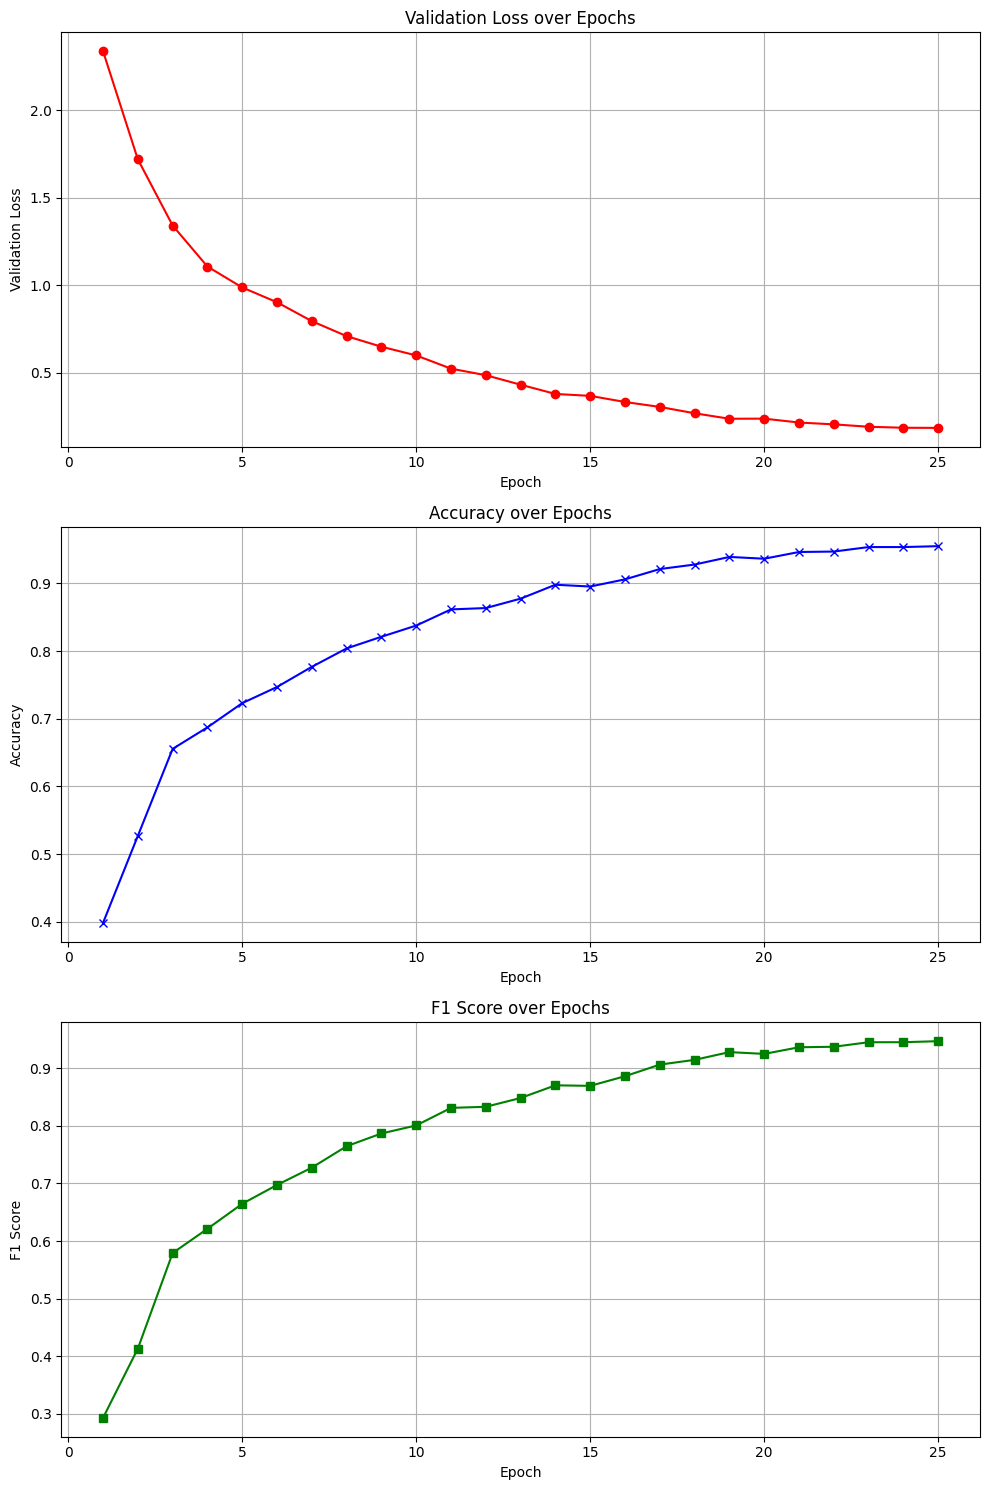

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 15))  # 3 แถว 1 คอลัมน์

# กราฟ Validation Loss
axes[0].plot(history["epoch"], history["Validation Loss"], color="red", marker='o')
axes[0].set_title("Validation Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Loss")
axes[0].grid(True)

# กราฟ Accuracy
axes[1].plot(history["epoch"], history["accuracy"], color="blue", marker='x')
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)

# กราฟ F1 Score
axes[2].plot(history["epoch"], history["f1"], color="green", marker='s')
axes[2].set_title("F1 Score over Epochs")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1 Score")
axes[2].grid(True)

plt.tight_layout()
plt.show()



In [11]:
!pip install seaborn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
trainer.save_model("./my_trained_model")[:3]

In [13]:
from sklearn.metrics import accuracy_score , f1_score


# 7. ทดสอบทำนายข้อความใหม่
labels_test = ['0_ACTION', 'AAW_NON', 'BIOCHEM_ACTION', 'BIOCHEM_NON', 'CONSUMER_ACTION',
          'CONSUMER_NON', 'ETHANOL_ACTION', 'ETHANOL_NON', 'FINANCE_ACTION',
          'FINANCE_NON', 'GENERAL_ACTION', 'GENERAL_NON', 'HR_ACTION', 'HR_NON',
          'IT_ACTION', 'MKT_ACTION', 'PNP_ACTION', 'PNP_NON', 'POWER_ACTION',
          'POWER_NON', 'QM_ACTION', 'QM_NON', 'RGS_ACTION', 'RGS_NON', 'SSHE_ACTION',
          'SSHE_NON', 'SUGAR_ACTION', 'SUGAR_NON', 'TIS_ACTION', 'TIS_NON', 'UST_ACTION',
          'UST_NON']

labels = train_df['result'].tolist()
predicted_labels = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for text in texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {key: value.to(device) for key, value in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)

    predictions = torch.argmax(outputs.logits, dim=1)
    predicted_index = predictions.item()
    predicted_label = labels_test[predicted_index]

    predicted_labels.append(predicted_label)

print(predicted_labels[:5])
print(labels[:5])

accuracy = accuracy_score(labels,predicted_labels )
f1 = f1_score(labels, predicted_labels, average='weighted') 

print(f"Accuracy on test set: {accuracy:.4f}")
print(f"F1 Score on test set: {f1:.4f}")

['HR_ACTION', 'HR_ACTION', 'BIOCHEM_ACTION', 'POWER_NON', 'FINANCE_ACTION']
['HR_ACTION', 'HR_ACTION', 'BIOCHEM_ACTION', 'POWER_NON', 'FINANCE_ACTION']
Accuracy on test set: 0.9549
F1 Score on test set: 0.9474


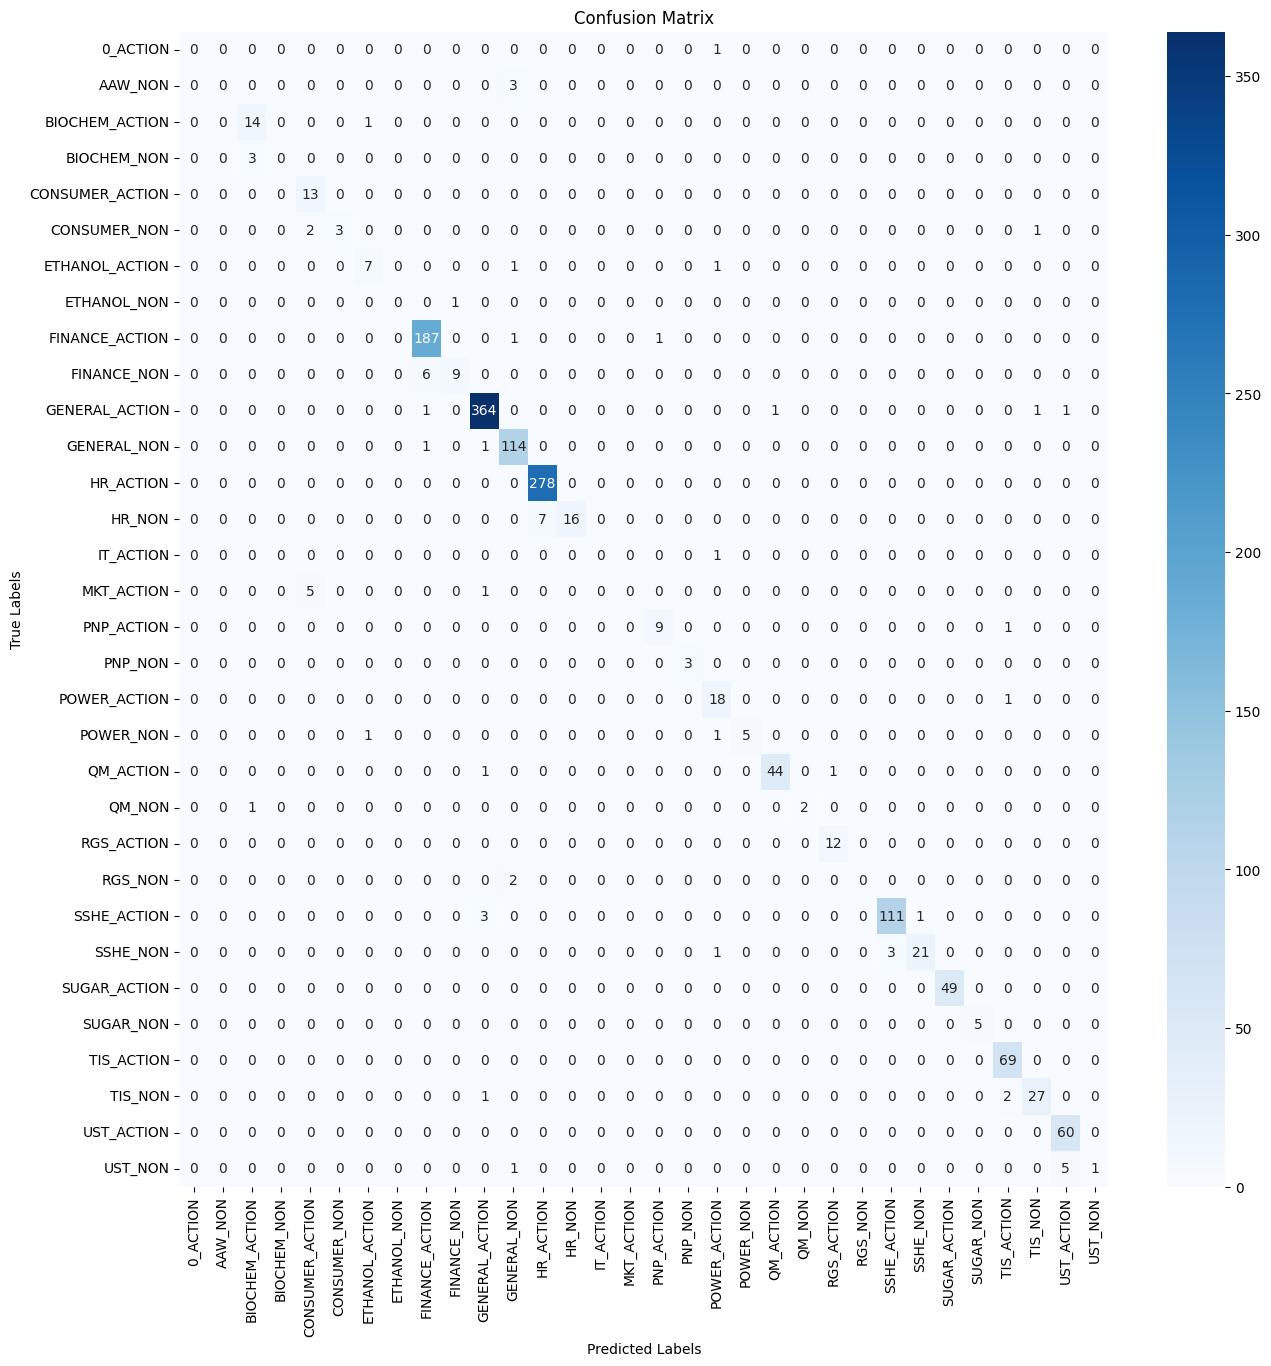

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# สร้าง confusion matrix
cm = confusion_matrix(labels, predicted_labels, labels=labels_test)

# plot heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_test, yticklabels=labels_test)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [ ]:
#ตอนแปลงpdf เป็น text ผมเผลอลบออกครับจะทำใหม่ก็จะใช้เวลานานครับแต่ผมได้ทำการ save เป้นไฟล์.csv 
#ไว้แล้วครับชื่อไฟล์ test_processed.csv 

In [ ]:
test_df = pd.read_csv('/kaggle/input/pdf-to-text/test_processed.csv')

In [ ]:
import torch
import pandas as pd

labels = ['0_ACTION', 'AAW_NON', 'BIOCHEM_ACTION', 'BIOCHEM_NON', 'CONSUMER_ACTION',
          'CONSUMER_NON', 'ETHANOL_ACTION', 'ETHANOL_NON', 'FINANCE_ACTION',
          'FINANCE_NON', 'GENERAL_ACTION', 'GENERAL_NON', 'HR_ACTION', 'HR_NON',
          'IT_ACTION', 'MKT_ACTION', 'PNP_ACTION', 'PNP_NON', 'POWER_ACTION',
          'POWER_NON', 'QM_ACTION', 'QM_NON', 'RGS_ACTION', 'RGS_NON', 'SSHE_ACTION',
          'SSHE_NON', 'SUGAR_ACTION', 'SUGAR_NON', 'TIS_ACTION', 'TIS_NON', 'UST_ACTION',
          'UST_NON']

texts = test_df['text_proc'].tolist()

submission = pd.read_csv("/kaggle/input/mitr-phol-gen-ai-hackathon/submission.csv")

predicted_labels = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

for text in texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {key: value.to(device) for key, value in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)

    predictions = torch.argmax(outputs.logits, dim=1)
    predicted_index = predictions.item()
    predicted_label = labels[predicted_index]

    predicted_labels.append(predicted_label)

submission['result'] = predicted_labels

print("สร้างไฟล์สำเร็จ")
print("ตัวอย่าง label ที่ 1:", predicted_labels[1])

#ถ้าต้องการบันทึกไฟล์เพื่อส่งผลลัพธ์
submission.to_csv("submission.csv", index=False)

In [ ]:
#ไฟล์ submission.csv เป็นไฟล์ที่พวกผมได้ทำการให้โมเดลทำการทำนายมาในช่วงที่ทดสอบโมเดลครับเหตุผลที่ส่งแบบนี้เพราะ
#ตอนที่กด Submit มันใช้เวลานานเกินไปครับและไม่มีแววว่าจะเสร็จครับผม

In [ ]:
import pandas as pd

In [ ]:
submission = pd.read_csv("/kaggle/input/submission/submission.csv")

submission.to_csv("submission.csv",index=False)